## 1. Imports e carregamento

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo dos gráficos
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

# 1. Carregar o dataset
df = pd.read_csv("../datasets/dados_tratados.csv", sep=";", encoding="utf-8")

print(f"Shape: {df.shape}")
print(f"Colunas: {len(df.columns)}")
df.head(3)

Shape: (17583, 227)
Colunas: 227


,SG_UF,CO_UF,NO_ENTIDADE,CO_ENTIDADE,TP_DEPENDENCIA,TP_LOCALIZACAO,IN_LOCAL_FUNC_PREDIO_ESCOLAR,TP_OCUPACAO_PREDIO_ESCOLAR,IN_LOCAL_FUNC_SOCIOEDUCATIVO,IN_LOCAL_FUNC_UNID_PRISIONAL,...,IN_ESP_EXCLUSIVA_MEDIO_INTEGR,IN_COMUM_EJA_FUND,IN_COMUM_EJA_MEDIO,IN_COMUM_EJA_PROF,IN_ESP_EXCLUSIVA_EJA_FUND,IN_ESP_EXCLUSIVA_EJA_MEDIO,IN_ESP_EXCLUSIVA_EJA_PROF,IN_COMUM_PROF,IN_ESP_EXCLUSIVA_PROF,IDEB_2025
0,RO,11,EEEMTI JUSCELINO KUBITSCHEK DE OLIVEIRA,11024968,2,1,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.1
1,RO,11,COLEGIO TIRADENTES DA POLICIA MILITAR - CTPM XI,11025638,2,1,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.8
2,RO,11,EEEFM CORA CORALINA,11006773,2,1,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.4


## Tratamento e criação do rótulo
## Rótulos IDEB 2025

| Sigla | Significado      | Faixa                  |
|-------|------------------|------------------------|
| SS    | Superior         | 9,0 a 10               |
| MS    | Médio Superior   | 7,0 a 8,9              |
| MM    | Médio            | 5,0 a 6,9              |
| MI    | Médio Inferior   | 3,0 a 4,9              |
| II    | Inferior         | 0,0 a 2,9              |
| SR    | Sem Rendimento   | Zero (ou ausente/nulo) |

In [15]:
# 2. Garantir que IDEB_2025 seja numérico
df["IDEB_2025"] = pd.to_numeric(
    df["IDEB_2025"].astype(str).str.replace(",", ".", regex=False),
    errors="coerce"
)

# 3. Função de classificação robusta
def classificar_ideb(valor):
    if pd.isna(valor) or valor == 0 or valor >= 88888:
        return "SR"
    if 9.0 <= valor <= 10.0:
        return "SS"
    if 7.0 <= valor < 9.0:
        return "MS"
    if 5.0 <= valor < 7.0:
        return "MM"
    if 3.0 <= valor < 5.0:
        return "MI"
    if 0.0 < valor < 3.0:
        return "II"
    return "SR"

# 4. Aplicar
df["ROTULO_IDEB"] = df["IDEB_2025"].apply(classificar_ideb)

# 5. Ordenar categoricamente (para gráficos na ordem correta)
ordem = ["SS", "MS", "MM", "MI", "II", "SR"]
df["ROTULO_IDEB"] = pd.Categorical(df["ROTULO_IDEB"], categories=ordem, ordered=True)

# 6. Diagnóstico
print("Distribuição dos rótulos:")
print(df["ROTULO_IDEB"].value_counts().reindex(ordem))

print(f"\nTotal de registros: {len(df)}")
print(f"IDEB nulos: {df['IDEB_2025'].isna().sum()}")

Distribuição dos rótulos:
ROTULO_IDEB
SS        0
MS       40
MM     3756
MI    13517
II      270
SR        0
Name: count, dtype: int64

Total de registros: 17583
IDEB nulos: 0


C:\Users\clara\AppData\Local\Temp\ipykernel_20720\2653278726.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["ROTULO_IDEB"] = df["IDEB_2025"].apply(classificar_ideb)


## 3. Gráfico de barras (distribuição geral)

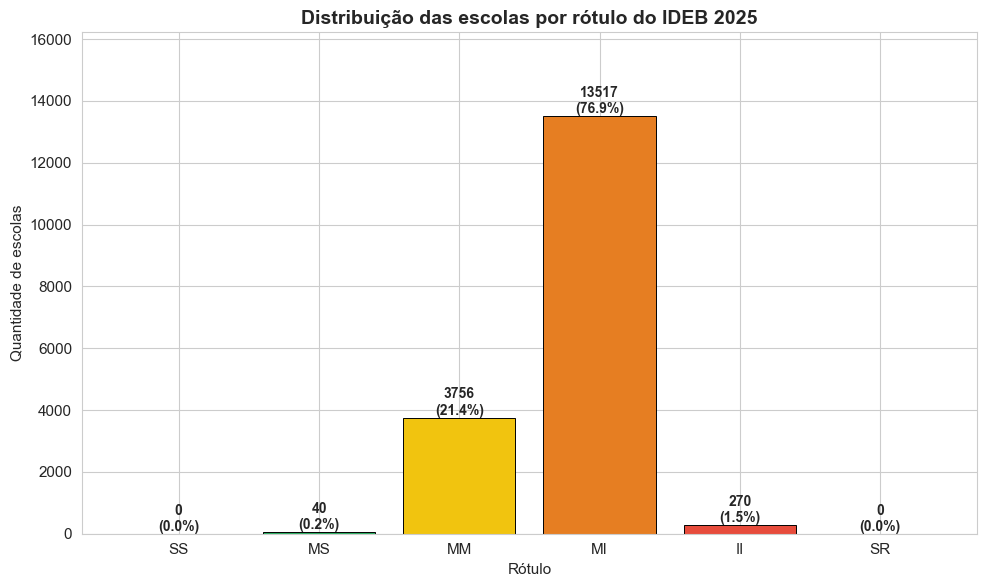

In [16]:
# 7. Gráfico de barras
contagem = df["ROTULO_IDEB"].value_counts().reindex(ordem)

cores = {
    "SS": "#2ecc71",   # verde
    "MS": "#27ae60",   # verde escuro
    "MM": "#f1c40f",   # amarelo
    "MI": "#e67e22",   # laranja
    "II": "#e74c3c",   # vermelho
    "SR": "#95a5a6"    # cinza
}

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(contagem.index, contagem.values,
              color=[cores[c] for c in contagem.index],
              edgecolor="black", linewidth=0.7)

# Rótulos em cima das barras
for bar, valor in zip(bars, contagem.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{valor}\n({valor/len(df)*100:.1f}%)",
            ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_title("Distribuição das escolas por rótulo do IDEB 2025",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Rótulo")
ax.set_ylabel("Quantidade de escolas")
ax.set_ylim(0, contagem.max() * 1.20)
plt.tight_layout()
plt.show()

## 4. Gráfico de pizza (proporção)

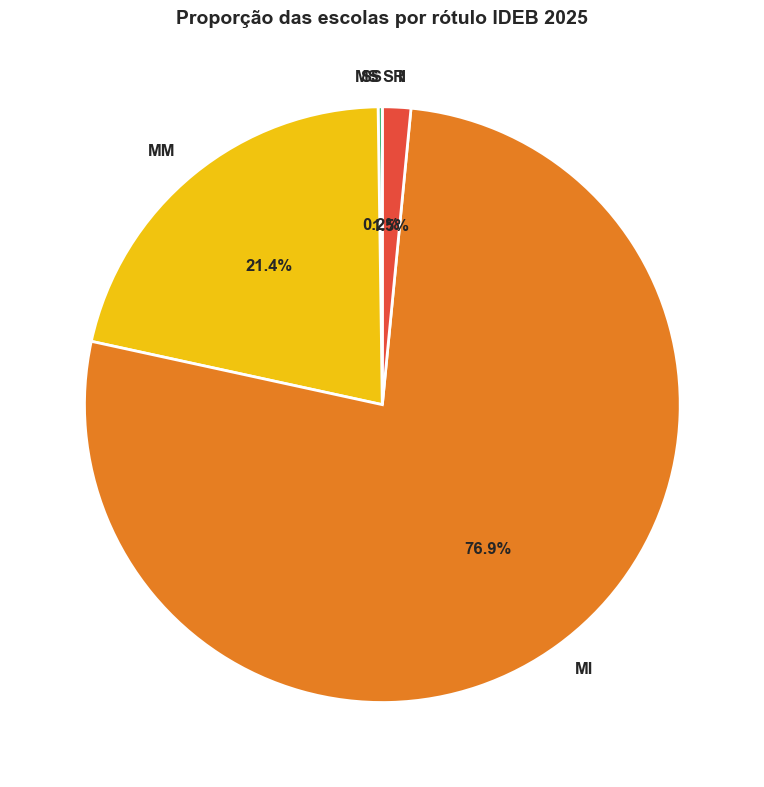

In [17]:
# 8. Gráfico de pizza
fig, ax = plt.subplots(figsize=(8, 8))
contagem_pie = df["ROTULO_IDEB"].value_counts().reindex(ordem)

ax.pie(
    contagem_pie.values,
    labels=contagem_pie.index,
    autopct=lambda p: f"{p:.1f}%" if p > 0 else "",
    colors=[cores[c] for c in contagem_pie.index],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    textprops={"fontsize": 12, "fontweight": "bold"}
)
ax.set_title("Proporção das escolas por rótulo IDEB 2025",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Distribuição por UF (barras empilhadas)

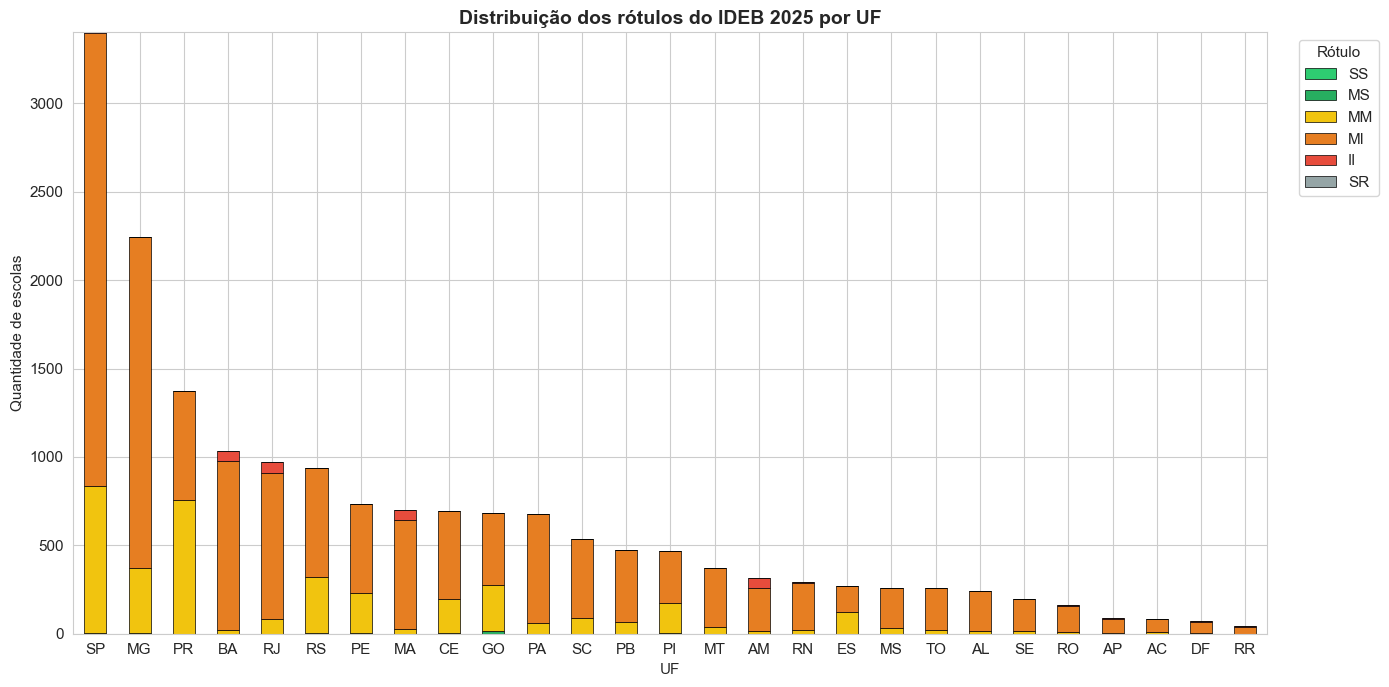

In [18]:
# 9. Distribuição por UF
tabela_uf = pd.crosstab(df["SG_UF"], df["ROTULO_IDEB"]).reindex(columns=ordem, fill_value=0)

# Ordenar UFs pela quantidade total
tabela_uf["_total"] = tabela_uf.sum(axis=1)
tabela_uf = tabela_uf.sort_values("_total", ascending=False).drop(columns="_total")

fig, ax = plt.subplots(figsize=(14, 7))
tabela_uf.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=[cores[c] for c in ordem],
    edgecolor="black",
    linewidth=0.5
)

ax.set_title("Distribuição dos rótulos do IDEB 2025 por UF",
             fontsize=14, fontweight="bold")
ax.set_xlabel("UF")
ax.set_ylabel("Quantidade de escolas")
ax.legend(title="Rótulo", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Boxplot do IDEB por rótulo (validação visual)

C:\Users\clara\AppData\Local\Temp\ipykernel_20720\3951165946.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


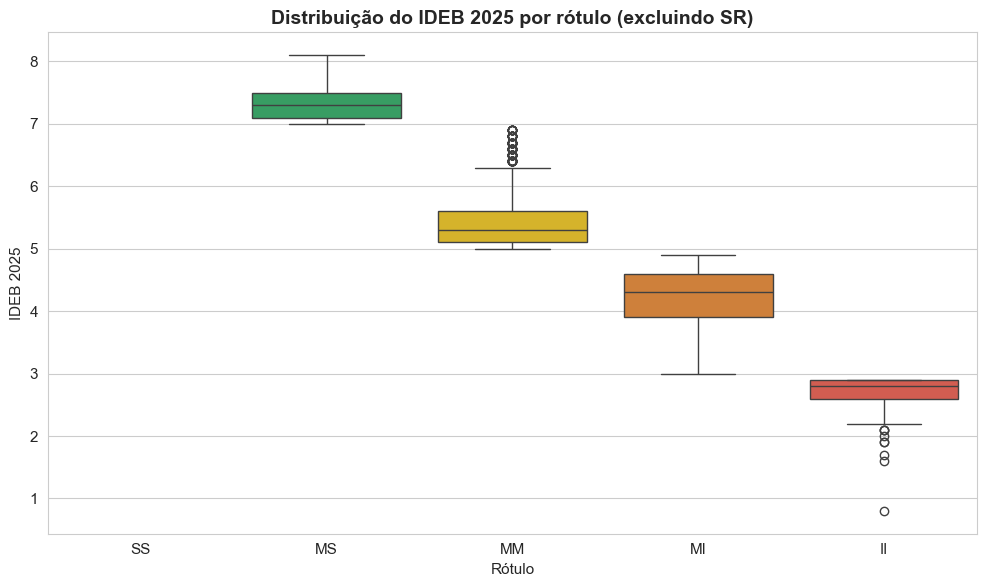

In [19]:
# 10. Boxplot para validar a classificação
df_validos = df[df["ROTULO_IDEB"] != "SR"].copy()

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(
    data=df_validos,
    x="ROTULO_IDEB",
    y="IDEB_2025",
    order=[c for c in ordem if c != "SR"],
    palette=[cores[c] for c in ordem if c != "SR"],
    ax=ax
)
ax.set_title("Distribuição do IDEB 2025 por rótulo (excluindo SR)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Rótulo")
ax.set_ylabel("IDEB 2025")
plt.tight_layout()
plt.show()

## 8. Resumo estatístico por rótulo

In [20]:
# 12. Resumo estatístico
resumo = df.groupby("ROTULO_IDEB", observed=True)["IDEB_2025"].agg(
    ["count", "mean", "min", "max"]
).round(2)
resumo.columns = ["Qtd", "Média", "Mínimo", "Máximo"]
print(resumo)

               Qtd  Média  Mínimo  Máximo
ROTULO_IDEB                              
MS              40   7.35     7.0     8.1
MM            3756   5.40     5.0     6.9
MI           13517   4.20     3.0     4.9
II             270   2.68     0.8     2.9


## Salvar dataset

In [21]:
df.to_csv("../datasets/dados_tratados_classificacao.csv", sep=";", index=False, encoding="utf-8")
print("✅ Arquivo salvo: dados_tratados_classificacao.csv")

✅ Arquivo salvo: dados_tratados_classificacao.csv
